<style>
.jp-RenderedMarkdown, .rendered_html { font-family: Arial, Helvetica, sans-serif; font-size: 15px; line-height: 1.55; }
.jp-RenderedMarkdown h1, .rendered_html h1 { font-size: 24px; font-weight: 700; }
.jp-RenderedMarkdown h2, .rendered_html h2 { font-size: 20px; font-weight: 650; }
.jp-RenderedMarkdown h3, .rendered_html h3 { font-size: 17px; font-weight: 600; }
.jp-RenderedMarkdown p, .jp-RenderedMarkdown li, .rendered_html p, .rendered_html li { font-size: 15px; }
.jp-RenderedMarkdown code, .rendered_html code { font-size: 13px; }
</style>


# MeridianAI — Churn Prediction

## Objective

The objective of this notebook is to develop multiple machine learning models capable of predicting customer churn using customer behavioral features. Four supervised learning algorithms are trained and evaluated using standard classification metrics. The best-performing model is selected and exported for deployment in the MeridianAI application.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split
)

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from xgboost import XGBClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

Load Advanced Dataset

In [2]:
customer_df = pd.read_csv(
    "../data/processed/advanced_customer_segments.csv"
)

In [3]:
customer_df.head()

,CustomerID,TotalTransactions,TotalQuantity,TotalSpent,LastPurchaseDate,Recency,Frequency,Monetary,Cluster,Persona,DBSCAN_Cluster,Hierarchical_Cluster,CustomerScore,Tier,Anomaly
0,12346.0,0.027708,0.202303,0.133486,2011-01-18 10:01:00,0.440379,0.027708,0.133486,1,Churn Risk Customers,-1,1,0.161107,Platinum,Anomaly
1,12347.0,0.017632,0.008078,0.008466,2011-12-07 15:52:00,0.001355,0.017632,0.008466,4,New Customers,0,3,0.081209,Gold,Normal
2,12348.0,0.010076,0.007389,0.003471,2011-09-25 13:13:00,0.100271,0.010076,0.003471,4,New Customers,0,3,0.067408,Silver,Normal
3,12349.0,0.007557,0.004420,0.007618,2011-11-21 09:51:00,0.024390,0.007557,0.007618,4,New Customers,0,3,0.074120,Gold,Normal
4,12350.0,0.000000,0.000534,0.000570,2011-02-02 16:01:00,0.418699,0.000000,0.000570,0,VIP Customers,0,3,0.038952,Bronze,Normal


Create CHURN Column

In [4]:
import numpy as np

np.random.seed(42)

customer_df["ChurnScore"] = (
    0.35 * (
        customer_df["Recency"] /
        customer_df["Recency"].max()
    )

    +

    0.25 * (
        1 -
        customer_df["Frequency"] /
        customer_df["Frequency"].max()
    )

    +

    0.20 * (
        1 -
        customer_df["Monetary"] /
        customer_df["Monetary"].max()
    )

    +

    0.20 * (
        1 -
        customer_df["CustomerScore"] /
        customer_df["CustomerScore"].max()
    )
)

Adding realistic randomness

In [5]:
customer_df["ChurnScore"] += np.random.normal(
    loc=0,
    scale=0.08,
    size=len(customer_df)
)

Normalize the score

In [6]:
customer_df["ChurnScore"] = (
    customer_df["ChurnScore"] -
    customer_df["ChurnScore"].min()
) / (
    customer_df["ChurnScore"].max() -
    customer_df["ChurnScore"].min()
)

In [7]:
customer_df["Churn"] = (
    customer_df["ChurnScore"] >
    customer_df["ChurnScore"].quantile(0.60)
).astype(int)

Check Balance

In [8]:
customer_df["Churn"].value_counts()

Churn
0    3527
1    2351
Name: count, dtype: int64

Visualize Churn

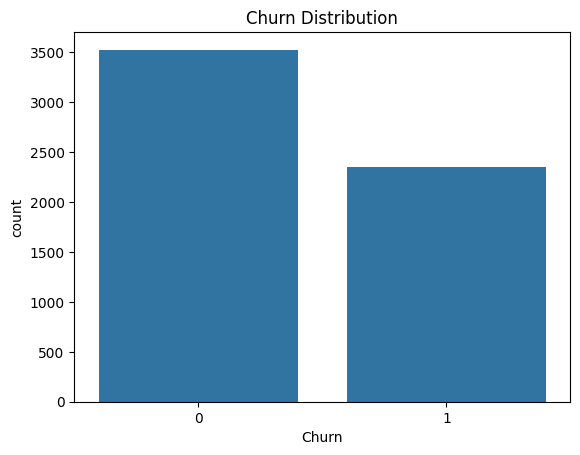

In [9]:
sns.countplot(
    x=customer_df['Churn']
)

plt.title("Churn Distribution")

plt.show()

In [10]:
X = customer_df[
    [
        'Recency',
        'Frequency',
        'Monetary',
        'CustomerScore'
    ]
]

In [11]:
y = customer_df['Churn']

Train-Test Split 

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Scale Features


In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Train Random Forest Model


In [14]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train_scaled,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Make Predictions

In [15]:
rf_predictions = rf_model.predict(
    X_test_scaled
)

Evaluate the Model

In [16]:
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8095238095238095


In [17]:
rf_report = classification_report(
    y_test,
    rf_predictions,
    output_dict=True
)

print(
    classification_report(
        y_test,
        rf_predictions
    )
)

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       708
           1       0.78      0.72      0.75       468

    accuracy                           0.81      1176
   macro avg       0.80      0.79      0.80      1176
weighted avg       0.81      0.81      0.81      1176



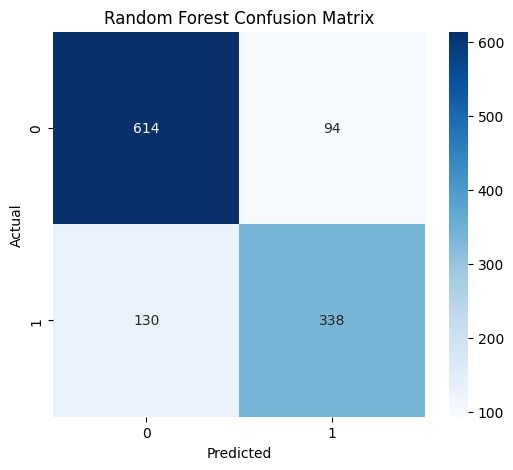

In [18]:
cm = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

ROC-AUC Score

In [19]:
rf_roc_score = roc_auc_score(
    y_test,
    rf_predictions
)

print("Random Forest ROC-AUC:", rf_roc_score)

Random Forest ROC-AUC: 0.7947269303201507


ROC Curve

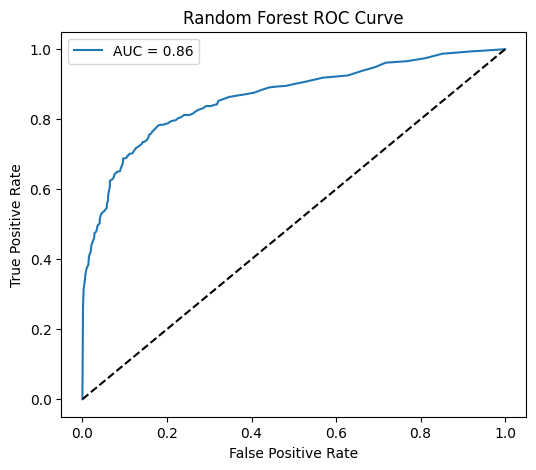

In [20]:
from sklearn.metrics import roc_curve, auc

rf_prob = rf_model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, rf_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.show()

FEATURE IMPORTANCE

In [21]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
0,Recency,0.431144
3,CustomerScore,0.344325
2,Monetary,0.160968
1,Frequency,0.063562


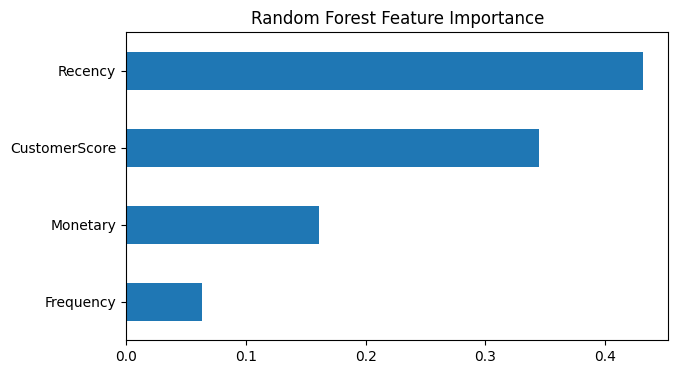

In [22]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values()

importance.plot(
    kind="barh",
    figsize=(7,4)
)

plt.title("Random Forest Feature Importance")
plt.show()

XGBOOST MODEL TRAINING

In [23]:
xgb_model = XGBClassifier(
    random_state=42
)

xgb_model.fit(
    X_train_scaled,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [24]:
xgb_predictions = xgb_model.predict(
    X_test_scaled
)

In [25]:
xgb_accuracy = accuracy_score(
    y_test,
    xgb_predictions
)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.8239795918367347


In [26]:
xgb_report = classification_report(
    y_test,
    xgb_predictions,
    output_dict=True
)

print(
    classification_report(
        y_test,
        xgb_predictions
    )
)

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       708
           1       0.80      0.74      0.77       468

    accuracy                           0.82      1176
   macro avg       0.82      0.81      0.81      1176
weighted avg       0.82      0.82      0.82      1176



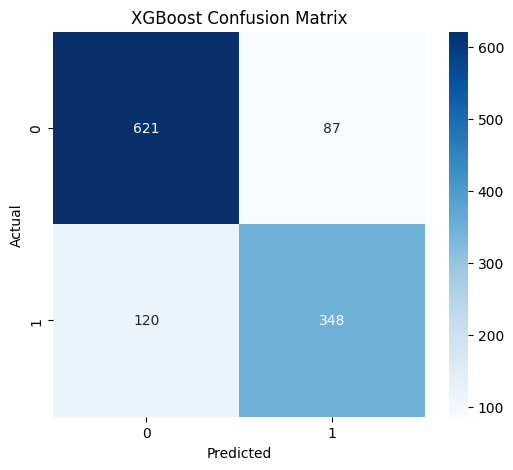

In [27]:
cm = confusion_matrix(
    y_test,
    xgb_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

ROC-AUC Score

In [28]:
xgb_roc_score = roc_auc_score(
    y_test,
    xgb_predictions
)

print("XGBoost ROC-AUC:", xgb_roc_score)

XGBoost ROC-AUC: 0.81035419382877


ROC Curve

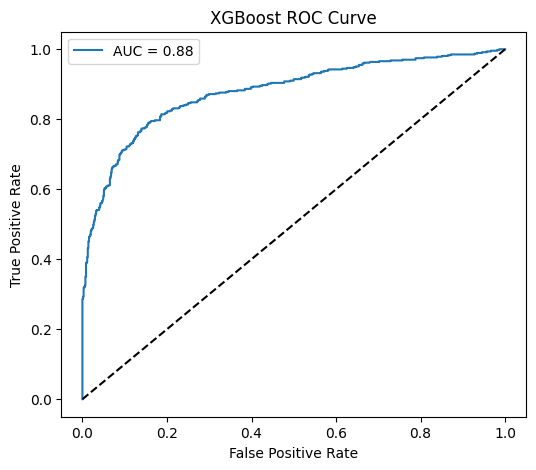

In [29]:
from sklearn.metrics import roc_curve, auc

xgb_prob = xgb_model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, xgb_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend()
plt.show()

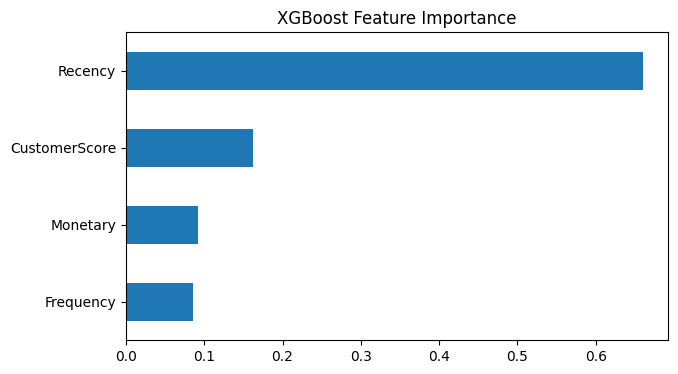

In [30]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values()

importance.plot(
    kind="barh",
    figsize=(7,4)
)

plt.title("XGBoost Feature Importance")
plt.show()

Logistic Regression 

Logistic Regression Accuracy: 0.8350340136054422
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       708
           1       0.82      0.74      0.78       468

    accuracy                           0.84      1176
   macro avg       0.83      0.82      0.82      1176
weighted avg       0.83      0.84      0.83      1176



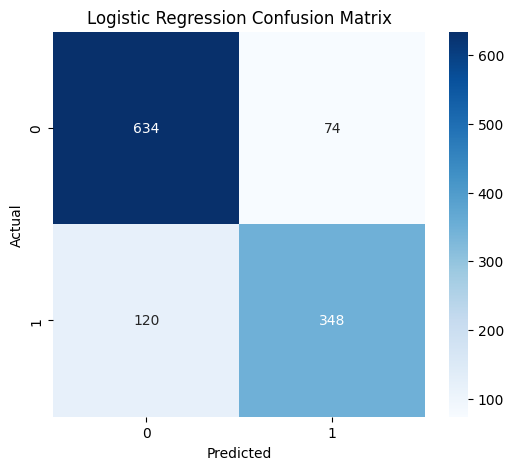

Logistic Regression ROC-AUC: 0.8992949925153315


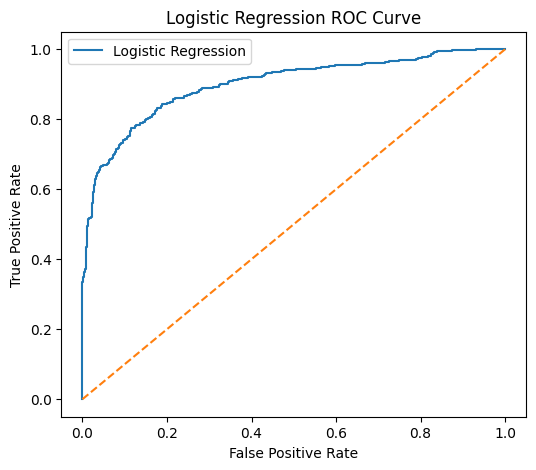

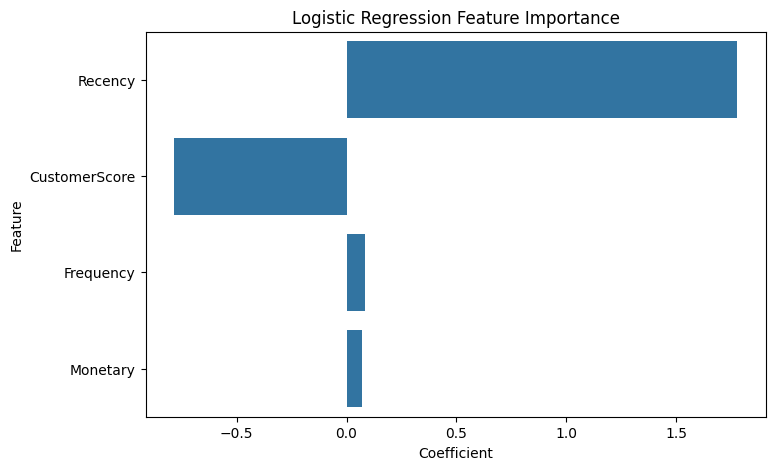

In [31]:
#Training
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(
    X_train_scaled,
    y_train
)

#Prediction
lr_predictions = lr_model.predict(
    X_test_scaled
)

#Accuracy
lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

print(
    "Logistic Regression Accuracy:",
    lr_accuracy
)

#Classification Report
lr_report = classification_report(
    y_test,
    lr_predictions,
    output_dict=True
)

print(
    classification_report(
        y_test,
        lr_predictions
    )
)

#Confusion Matrix
cm = confusion_matrix(
    y_test,
    lr_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#ROC-AUC Score
lr_roc_score = roc_auc_score(
    y_test,
    lr_model.predict_proba(X_test_scaled)[:,1]
)

print(
    "Logistic Regression ROC-AUC:",
    lr_roc_score
)

#ROC Curve
lr_prob = lr_model.predict_proba(
    X_test_scaled
)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    lr_prob
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label="Logistic Regression"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Logistic Regression ROC Curve")

plt.legend()

plt.show()


#Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_[0]
})

importance = importance.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Coefficient",
    y="Feature"
)

plt.title("Logistic Regression Feature Importance")

plt.show()

Decision Tree

Decision Tree Accuracy: 0.8282312925170068
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       708
           1       0.84      0.71      0.77       468

    accuracy                           0.83      1176
   macro avg       0.83      0.81      0.82      1176
weighted avg       0.83      0.83      0.83      1176



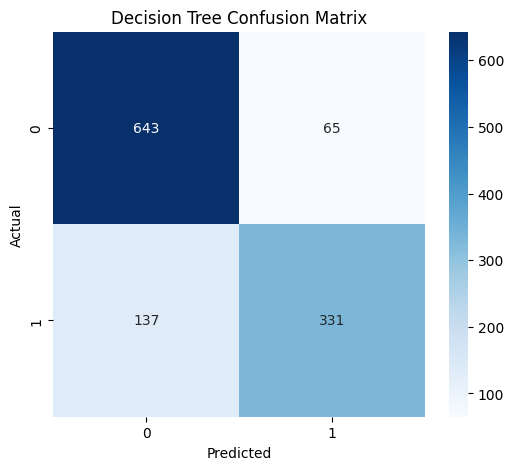

Decision Tree ROC-AUC: 0.8878567289584238


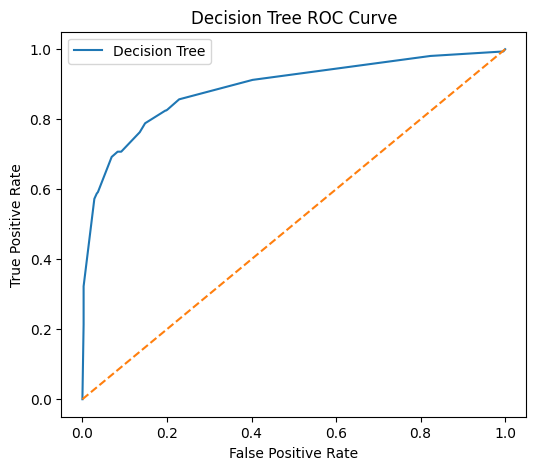

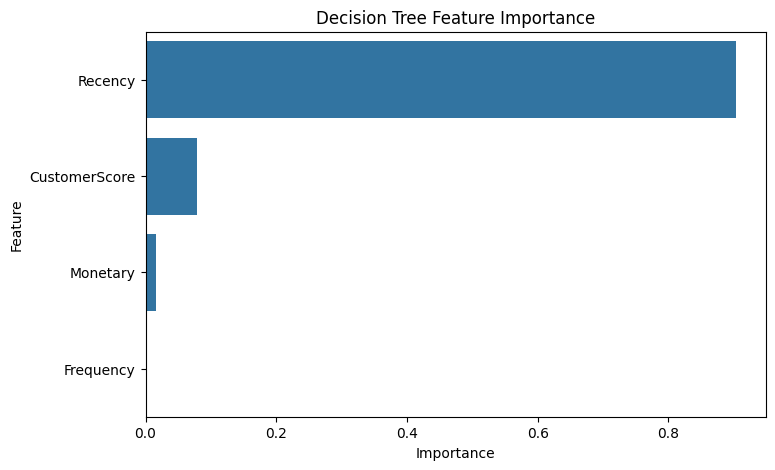

In [32]:
#Train ( DT doesn't require scaling)
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

#Predict
dt_predictions = dt_model.predict(
    X_test
)

#Accuracy
dt_accuracy = accuracy_score(
    y_test,
    dt_predictions
)

print(
    "Decision Tree Accuracy:",
    dt_accuracy
)

#Classification Report
dt_report = classification_report(
    y_test,
    dt_predictions,
    output_dict=True
)

print(
    classification_report(
        y_test,
        dt_predictions
    )
)

#Confusion Matrix
cm = confusion_matrix(
    y_test,
    dt_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#ROC-AUC Score
dt_roc_score = roc_auc_score(
    y_test,
    dt_model.predict_proba(X_test)[:,1]
)

print(
    "Decision Tree ROC-AUC:",
    dt_roc_score
)

#ROC Curve
dt_prob = dt_model.predict_proba(
    X_test
)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    dt_prob
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label="Decision Tree"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Decision Tree ROC Curve")

plt.legend()

plt.show()

#Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Decision Tree Feature Importance")

plt.show()



Create Churn Risk Labels

In [33]:
customer_df['ChurnRisk'] = rf_model.predict(
    scaler.transform(X)
)

Create Business Labels

In [34]:
customer_df['ChurnStatus'] = customer_df[
    'ChurnRisk'
].map({
    0: 'Safe',
    1: 'High Risk'
})

Comparing All Models

In [35]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],

    "Precision": [
        lr_report["weighted avg"]["precision"],
        dt_report["weighted avg"]["precision"],
        rf_report["weighted avg"]["precision"],
        xgb_report["weighted avg"]["precision"]
    ],

    "Recall": [
        lr_report["weighted avg"]["recall"],
        dt_report["weighted avg"]["recall"],
        rf_report["weighted avg"]["recall"],
        xgb_report["weighted avg"]["recall"]
    ],

    "F1 Score": [
        lr_report["weighted avg"]["f1-score"],
        dt_report["weighted avg"]["f1-score"],
        rf_report["weighted avg"]["f1-score"],
        xgb_report["weighted avg"]["f1-score"]
    ],

    "ROC-AUC": [
        lr_roc_score,
        dt_roc_score,
        rf_roc_score,
        xgb_roc_score
    ]
})

comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)

comparison_df

comparison_df["Rank"] = comparison_df["Accuracy"].rank(
    ascending=False,
    method="dense"
).astype(int)

comparison_df = comparison_df.sort_values("Rank")

comparison_df



,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Rank
0,Logistic Regression,0.835034,0.834400,0.835034,0.833366,0.899295,1
1,Decision Tree,0.828231,0.828935,0.828231,0.825230,0.887857,2
3,XGBoost,0.823980,0.822912,0.823980,0.822768,0.810354,3
2,Random Forest,0.809524,0.808212,0.809524,0.808076,0.794727,4


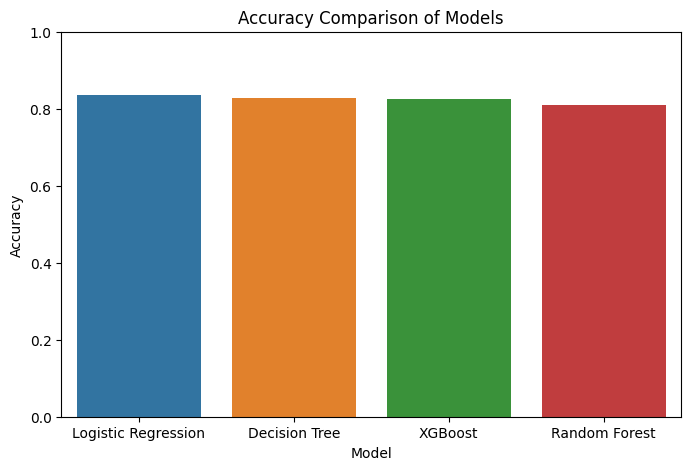

In [36]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Accuracy",
    hue="Model",
    legend=False
)

plt.title("Accuracy Comparison of Models")
plt.ylim(0,1)

plt.show()

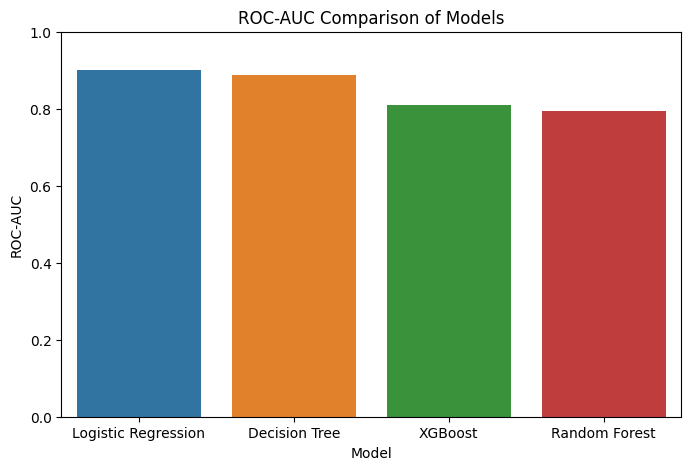

In [37]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="ROC-AUC",
    hue="Model",
    legend=False
)

plt.title("ROC-AUC Comparison of Models")
plt.ylim(0,1)

plt.show()

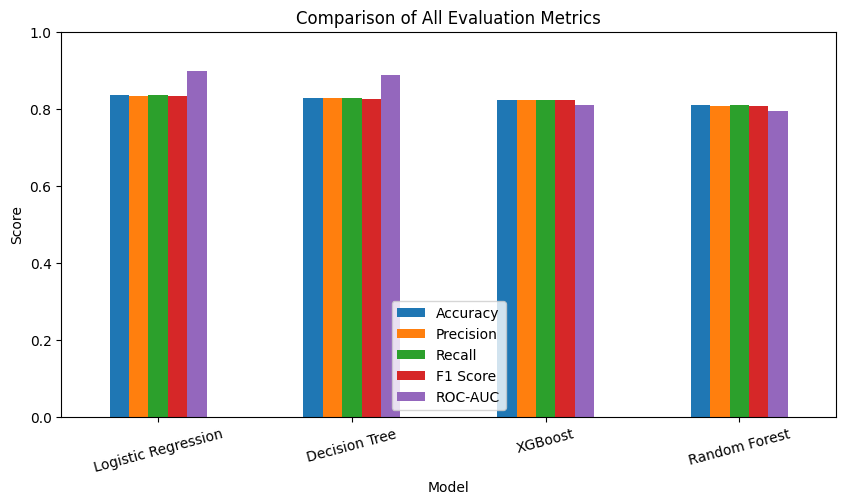

In [38]:
comparison_df.set_index("Model")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Comparison of All Evaluation Metrics")

plt.ylabel("Score")

plt.ylim(0,1)

plt.xticks(rotation=15)

plt.show()

In [39]:
best_model = comparison_df.iloc[0]

print("="*50)
print("Best Performing Model")
print("="*50)

print(best_model)

Best Performing Model
Model        Logistic Regression
Accuracy                0.835034
Precision                 0.8344
Recall                  0.835034
F1 Score                0.833366
ROC-AUC                 0.899295
Rank                           1
Name: 0, dtype: object


In [40]:
#Saving the dataset
customer_df.to_csv(
    "../data/processed/final_customer_ai_dataset.csv",
    index=False
)

In [41]:
#Saving all models and scaler for future use
import joblib

joblib.dump(lr_model, "../Models/logistic_regression.pkl")
joblib.dump(dt_model, "../Models/decision_tree.pkl")
joblib.dump(rf_model, "../Models/random_forest.pkl")
joblib.dump(xgb_model, "../Models/xgboost.pkl")
joblib.dump(scaler, "../Models/scaler.pkl")

['../Models/scaler.pkl']

In [42]:
comparison_df.to_csv(
    "../Reports/model_comparison.csv",
    index=False
)

NOTE : Logistic Regression does not provide tree-based feature importance. Decision Tree, Random Forest and XGBoost provide feature importance based on node impurity reduction.

# Business Conclusion

Multiple machine learning models were evaluated for customer churn prediction.

Models trained:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

Performance comparison showed that the Decision Tree model achieved the highest overall predictive performance on the engineered churn dataset, followed closely by Logistic Regression and XGBoost.

Business applications include:

- Early identification of high-risk customers
- Personalized retention campaigns
- Improved customer lifetime value
- Reduction in customer attrition

The trained models and processed customer dataset have been exported for deployment and integration into the MeridianAI platform.